# Real-world Data Wrangling
### Fullname:
### ID:
### Class:

## 1. Gather data


### **1.1.** Problem Statement

This project aims to practice my skills of data wrangling using real-world datasets. 

In this dataset, I would like to answer the following research questions:

**Question 1:** Tốc độ tăng trưởng số lượng thí sinh dự thi năm 2025 so với giai đoạn 2020-2024 thay đổi ra sao, và sự gia tăng khối lượng thí sinh này tạo ra áp lực cạnh tranh (tỷ lệ chọi) như thế nào lên các nhóm trường Đại học top đầu?

**Question 2:** Có sự dịch chuyển bất thường nào trong phổ điểm của các môn học từng có hiện tượng "tăng vọt" về điểm số trong năm 2024 (như Lịch sử, Địa lý, Ngữ Văn) hay không? Đề thi năm 2025 đã đưa phổ điểm các môn này về mức cân bằng hay tiếp tục lạm phát điểm?

**Question 3:** Ngưỡng điểm để lọt vào "Top 5% và Top 10% thí sinh xuất sắc nhất" ở các khối thi truyền thống (A, A1, B, C, D) năm 2025 dịch chuyển bao nhiêu điểm so với 2024?

**Question 4:** Tại các vùng điểm nóng cạnh tranh (từ 24 đến 28 điểm), số lượng thí sinh tích lũy dư thừa hay thiếu hụt bao nhiêu người so với năm 2024 ở từng khối thi; kết hợp với biến số về chỉ tiêu và phương thức xét tuyển, điểm chuẩn của các trường Đại học top đầu (như Bách Khoa, Ngoại Thương, Kinh Tế Quốc Dân,...) sẽ biến động theo xu hướng nào?

**Question 5:** Mối tương quan điểm số giữa các môn học (Ví dụ: Toán và Ngoại ngữ, hoặc Ngữ Văn và Lịch Sử) năm 2025 có sự thay đổi nào không? Những thí sinh học giỏi môn Tự nhiên có xu hướng đạt điểm cao môn Ngoại ngữ như các năm trước hay không?

**Question 6:** Bản đồ phân bổ trung vị điểm và "độ lệch chuẩn" năm 2025 cho thấy khoảng cách về năng lực học tập và chất lượng giáo dục giữa các thành phố lớn (Hà Nội, TP.HCM) với các khu vực miền núi/vùng ven đang thu hẹp hay ngày càng giãn rộng?



### **1.2.** Gather at least two datasets using two different data gathering methods


Gather each of the 2 pieces of data from different sources:


In [5]:
# Analysis for Question 3: Percentile Shift Analysis (2024 vs 2025)
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [6]:
# Method 1: Load historical datasets from local storage
data_files = {
    '2021': 'dataset/du_lieu_diem_thi_2021.csv',
    '2021_dot2': 'dataset/du_lieu_diem_thi_2021_dot_2.csv',
    '2022': 'dataset/du_lieu_diem_thi_2022.csv',
    '2023': 'dataset/du_lieu_diem_thi_2023.csv',
    '2024': 'dataset/du_lieu_diem_thi_2024.csv'
}

dfs_historical = {}
for key, path in data_files.items():
    if os.path.exists(path):
        dfs_historical[key] = pd.read_csv(path, low_memory=False)
        print(f"Successfully loaded {key} data: {dfs_historical[key].shape}")
    else:
        print(f"Warning: File not found at {path}")

Successfully loaded 2021 data: (987704, 27)
Successfully loaded 2021_dot2 data: (12086, 27)
Successfully loaded 2022 data: (995441, 27)
Successfully loaded 2023 data: (1022060, 27)
Successfully loaded 2024 data: (1061605, 27)


In [7]:
# Method 2: Load the latest 2025 datasets with curriculum differentiation
# This represents the new data format involving CT2006 (Old) and CT2018 (New) curricula
df_2025_old = pd.read_csv('dataset/du-lieu-diem-thi-2025-ct2006.csv', low_memory=False)
df_2025_new = pd.read_csv('dataset/du-lieu-diem-thi-2025-ct2018.csv', low_memory=False)

print(f"Loaded 2025 Old Curriculum (CT2006): {df_2025_old.shape}")
print(f"Loaded 2025 New Curriculum (CT2018): {df_2025_new.shape}")

Loaded 2025 Old Curriculum (CT2006): (22090, 27)
Loaded 2025 New Curriculum (CT2018): (1131136, 26)


In [8]:
# Write data to local file 


## 2. Assess data

I will assess the data both visually and programmatically to identify any data quality(content) issues and tidiness(structual) issues.

### Issue 1: Inconsistent Column Names and Structural Differences

In [9]:
# Inspecting column names across different years
for year, df in dfs_historical.items():
    print(f"Year {year} columns: {df.columns.tolist()[:]}")
print(f"2025 CT2006 columns: {df_2025_old.columns.tolist()[:]}")
print(f"2025 CT2018 columns: {df_2025_new.columns.tolist()[:]}")

Year 2021 columns: ['SBD', 'Nam', 'Tinh', 'SBD_New', 'Toan', 'NguVan', 'VatLy', 'HoaHoc', 'SinhHoc', 'LichSu', 'DiaLy', 'GDCD', 'NgoaiNgu', 'MaMonNgoaiNgu', 'TongDiem', 'KhoiA', 'KhoiA1', 'KhoiB', 'KhoiC', 'KhoiD', 'KHTN', 'KHXH', 'KhoiA02', 'KhoiC01', 'KhoiD07', 'TongDiemKHTN', 'TongDiemKHXH']
Year 2021_dot2 columns: ['SBD', 'Nam', 'Tinh', 'SBD_New', 'Toan', 'NguVan', 'VatLy', 'HoaHoc', 'SinhHoc', 'LichSu', 'DiaLy', 'GDCD', 'NgoaiNgu', 'MaMonNgoaiNgu', 'TongDiem', 'KhoiA', 'KhoiA1', 'KhoiB', 'KhoiC', 'KhoiD', 'KHTN', 'KHXH', 'KhoiA02', 'KhoiC01', 'KhoiD07', 'TongDiemKHTN', 'TongDiemKHXH']
Year 2022 columns: ['SBD', 'Nam', 'Tinh', 'SBD_New', 'Toan', 'NguVan', 'VatLy', 'HoaHoc', 'SinhHoc', 'LichSu', 'DiaLy', 'GDCD', 'NgoaiNgu', 'MaMonNgoaiNgu', 'TongDiem', 'KhoiA', 'KhoiA1', 'KhoiB', 'KhoiC', 'KhoiD', 'KHTN', 'KHXH', 'KhoiA02', 'KhoiC01', 'KhoiD07', 'TongDiemKHTN', 'TongDiemKHXH']
Year 2023 columns: ['SBD', 'Nam', 'Tinh', 'SBD_New', 'Toan', 'NguVan', 'VatLy', 'HoaHoc', 'SinhHoc', 'LichS

#### Observations:

- The 2025 CT2018 dataset introduces new subjects (Tin học, Công nghệ, Kinh tế & Pháp luật) that do not exist in the 2006 curriculum files.

### Issue 2: Incorrect Data Types (SBD as int, Year as short string)

In [10]:
# Check data types and samples for ALL available datasets
all_dfs = {**dfs_historical, '2025_CT2006': df_2025_old, '2025_CT2018': df_2025_new}

for name, df in all_dfs.items():
    print(f"--- Dataset: {name} ---")
    print(f"Data Types: SBD ({df['SBD'].dtype}), Nam ({df['Nam'].dtype})")
    display(df[['SBD', 'Nam']].head(2))
    print("\n")

--- Dataset: 2021 ---
Data Types: SBD (int64), Nam (int64)


,SBD,Nam
0,1000001,21
1,1000002,21




--- Dataset: 2021_dot2 ---
Data Types: SBD (int64), Nam (str)


,SBD,Nam
0,3000183,21-2
1,3000395,21-2




--- Dataset: 2022 ---
Data Types: SBD (int64), Nam (int64)


...

,SBD,Nam
0,1000001,24
1,1000002,24




--- Dataset: 2025_CT2006 ---
Data Types: SBD (int64), Nam (int64)


,SBD,Nam
0,1017985,25
1,1017986,25




--- Dataset: 2025_CT2018 ---
Data Types: SBD (int64), Nam (int64)


,SBD,Nam
0,1000001,25
1,1000002,25


#### Observations:

- `SBD` (Số báo danh) có thể được nhận diện là kiểu số nguyên, dẫn đến việc mất các số 0 ở đầu (ví dụ: mã tỉnh 01 Hà Nội).
- Cột `Nam` (Năm dự thi) có định dạng không đồng nhất giữa các đợt: ví dụ năm 2025 đang để là '25', hoặc đặc biệt như năm 2021 có 2 đợt thi nên đang hiển thị là '21_2'.
- Cần chuẩn hóa các giá trị này về một định dạng số nguyên hoặc chuỗi chuẩn để phục vụ việc sắp xếp và vẽ biểu đồ xu hướng.

### Issue 3: Missing Values in Subject Scores

In [11]:
# Check missing values count for ALL available datasets
all_dfs = {**dfs_historical, '2025_CT2006': df_2025_old, '2025_CT2018': df_2025_new}

for name, df in all_dfs.items():
    print(f"Missing values in {name}:")
    print(df.isnull().sum())
    print("-" * 30)

Missing values in 2021:
SBD                   0
Nam                   0
Tinh                  0
SBD_New               0
Toan              10340
NguVan            13263
VatLy            642620
HoaHoc           640985
SinhHoc          646415
LichSu           352978
DiaLy            358826
GDCD             455467
NgoaiNgu         119415
MaMonNgoaiNgu    119819
TongDiem         128778
KhoiA            644266
KhoiA1           655230
KhoiB            646463
KhoiC            359219
KhoiD            122729
KHTN             649681
KHXH             455725
KhoiA02          649644
KhoiC01          652011
KhoiD07          656546
TongDiemKHTN     657793
TongDiemKHXH     458689
dtype: int64
------------------------------
Missing values in 2021_dot2:
SBD                 0
Nam                 0
Tinh                0
SBD_New             0
Toan              106
NguVan            137
VatLy            7826
HoaHoc           7812
SinhHoc          7860
LichSu           4358
DiaLy            4409
GDCD         

#### Observations:

- **Giai đoạn trước 2025:** Có 3 môn thi bắt buộc (Toán, Ngữ văn, Ngoại ngữ). Việc thiếu điểm ở các môn này thường do thí sinh bỏ thi, lỡ giờ hoặc thuộc diện miễn thi. Các môn thuộc tổ hợp KHTN/KHXH là tự chọn nên việc thiếu điểm là bình thường.
- **Từ năm 2025 (Chương trình mới):** Chỉ còn 2 môn thi bắt buộc là Toán và Ngữ văn. Môn Ngoại ngữ cùng với các môn khác (Lịch sử, Vật lý, Hóa học, Sinh học, Địa lý, GD Kinh tế và Pháp luật, Tin học, Công nghệ) đã trở thành môn tự chọn. 
- **Hệ quả:** Tỷ lệ thiếu điểm (NaN) ở môn Ngoại ngữ từ năm 2025 sẽ tăng đáng kể so với các năm trước vì thí sinh không bắt buộc phải chọn môn này để tốt nghiệp. Đây là thay đổi quan trọng cần lưu ý khi so sánh phổ điểm môn Ngoại ngữ qua các thời kỳ.

## 3. Clean data
Clean the data to solve the 4 issues found in the assessing step.

In [12]:
# Make copies and define standardization functions
dfs_clean = {year: df.copy() for year, df in dfs_historical.items()}
df_2025_old_clean = df_2025_old.copy()
df_2025_new_clean = df_2025_new.copy()

import unidecode
def standardize_columns(df):
    df.columns = [unidecode.unidecode(col).replace(' ', '_').lower() for col in df.columns]
    return df

### Issue 1: Standardize Column Names

In [13]:
# Apply column standardization
for year in dfs_clean: dfs_clean[year] = standardize_columns(dfs_clean[year])
df_2025_old_clean = standardize_columns(df_2025_old_clean)
df_2025_new_clean = standardize_columns(df_2025_new_clean)

# Display standardized columns for ALL datasets
all_clean_dfs = {**dfs_clean, '2025_CT2006': df_2025_old_clean, '2025_CT2018': df_2025_new_clean}
for name, df in all_clean_dfs.items():
    print(f"Standardized {name} columns: {df.columns.tolist()[:]}")

Standardized 2021 columns: ['sbd', 'nam', 'tinh', 'sbd_new', 'toan', 'nguvan', 'vatly', 'hoahoc', 'sinhhoc', 'lichsu', 'dialy', 'gdcd', 'ngoaingu', 'mamonngoaingu', 'tongdiem', 'khoia', 'khoia1', 'khoib', 'khoic', 'khoid', 'khtn', 'khxh', 'khoia02', 'khoic01', 'khoid07', 'tongdiemkhtn', 'tongdiemkhxh']...
Standardized 2021_dot2 columns: ['sbd', 'nam', 'tinh', 'sbd_new', 'toan', 'nguvan', 'vatly', 'hoahoc', 'sinhhoc', 'lichsu', 'dialy', 'gdcd', 'ngoaingu', 'mamonngoaingu', 'tongdiem', 'khoia', 'khoia1', 'khoib', 'khoic', 'khoid', 'khtn', 'khxh', 'khoia02', 'khoic01', 'khoid07', 'tongdiemkhtn', 'tongdiemkhxh']...
Standardized 2022 columns: ['sbd', 'nam', 'tinh', 'sbd_new', 'toan', 'nguvan', 'vatly', 'hoahoc', 'sinhhoc', 'lichsu', 'dialy', 'gdcd', 'ngoaingu', 'mamonngoaingu', 'tongdiem', 'khoia', 'khoia1', 'khoib', 'khoic', 'khoid', 'khtn', 'khxh', 'khoia02', 'khoic01', 'khoid07', 'tongdiemkhtn', 'tongdiemkhxh']...
Standardized 2023 columns: ['sbd', 'nam', 'tinh', 'sbd_new', 'toan', 'nguv

### Issue 2: Fix Data Types

In [14]:
# Comprehensive standardization of data types and year formats
def fix_types(df):
    # 1. Standardize SBD to 8-digit string
    if 'sbd' in df.columns: 
        df['sbd'] = df['sbd'].astype(str).str.zfill(8)
    
    # 2. Standardize Year (Nam)
    if 'nam' in df.columns:
        df['nam'] = df['nam'].astype(str).str.replace(r'(_2|-2| đợt 2)', '', regex=True)
        df['nam'] = df['nam'].apply(lambda x: '20' + x if len(x) == 2 else x)
        df['nam'] = pd.to_numeric(df['nam'], errors='coerce')
    
    # 3. Convert all subject and block scores to numeric
    # List all possible subject/block columns from CT2006 and CT2018
    numeric_cols = [
        'toan', 'nguvan', 'ngoaingu', 'vatly', 'hoahoc', 'sinhhoc', 'lichsu', 'dialy', 'gdcd', 
        'kinhtephapluat', 'tinhoc', 'congnghecongnghiep', 'congnghenongnghiep',
        'tongdiem', 'khoia', 'khoia1', 'khoib', 'khoic', 'khoid', 'khoia02', 'khoic01', 'khoid07',
        'khtn', 'khxh', 'tongdiemkhtn', 'tongdiemkhxh', 'tinh', 'sbd_new'
    ]
    for col in numeric_cols:
        if col in df.columns: 
            df[col] = pd.to_numeric(df[col], errors='coerce')
    return df

for year in dfs_clean: dfs_clean[year] = fix_types(dfs_clean[year])
df_2025_old_clean = fix_types(df_2025_old_clean)
df_2025_new_clean = fix_types(df_2025_new_clean)

# Display results for verification
print("Verification after comprehensive cleaning:")
all_clean_dfs = {**dfs_clean, '2025_CT2006': df_2025_old_clean, '2025_CT2018': df_2025_new_clean}
for name, df in all_clean_dfs.items():
    print(f"{name}: SBD type={df['sbd'].dtype}, Nam samples={df['nam'].unique().tolist()}")
    display(df[['sbd', 'nam']].head(1))

Verification after comprehensive cleaning:
2021: SBD type=str, Nam samples=[2021]


,sbd,nam
0,01000001,2021


2021_dot2: SBD type=str, Nam samples=[2021]


,sbd,nam
0,03000183,2021


2022: SBD type=str, Nam samples=[2022]


...

,sbd,nam
0,01000001,2024


2025_CT2006: SBD type=str, Nam samples=[2025]


,sbd,nam
0,01017985,2025


2025_CT2018: SBD type=str, Nam samples=[2025]


,sbd,nam
0,01000001,2025


### Issue 3: Distinguish NaN from Zero

In [15]:
# Already handled by pd.to_numeric(errors='coerce') which preserves NaNs.

**Justification:** Keeping NaNs instead of zero prevents skewing average scores for subjects not taken.

### Issue 4: Add Metadata and Merge

In [16]:
# Add year and curriculum metadata
for year, df in dfs_clean.items():
    df['year_exam'] = int(year.split('_')[0]); df['curriculum'] = 'CT2006'
df_2025_old_clean['year_exam'] = 2025; df_2025_old_clean['curriculum'] = 'CT2006'
df_2025_new_clean['year_exam'] = 2025; df_2025_new_clean['curriculum'] = 'CT2018'

master_df = pd.concat(list(dfs_clean.values()) + [df_2025_old_clean, df_2025_new_clean], ignore_index=True)

**Justification:** Adding metadata enables cross-curriculum and chronological comparison in a single dataset.

### **Remove unnecessary variables and combine datasets**

In [17]:
# Final verification of the merged dataset
print(f"Master DataFrame shape: {master_df.shape}")
print("\nAll columns in master_df:")
print(master_df.columns.tolist())

# Display 5 random records (all columns should be visible now)
master_df.sample(5)

Master DataFrame shape: (5232122, 33)

All columns in master_df:
['sbd', 'nam', 'tinh', 'sbd_new', 'toan', 'nguvan', 'vatly', 'hoahoc', 'sinhhoc', 'lichsu', 'dialy', 'gdcd', 'ngoaingu', 'mamonngoaingu', 'tongdiem', 'khoia', 'khoia1', 'khoib', 'khoic', 'khoid', 'khtn', 'khxh', 'khoia02', 'khoic01', 'khoid07', 'tongdiemkhtn', 'tongdiemkhxh', 'year_exam', 'curriculum', 'kinhtephapluat', 'tinhoc', 'congnghecongnghiep', 'congnghenongnghiep']


,sbd,nam,tinh,sbd_new,toan,nguvan,vatly,hoahoc,sinhhoc,lichsu,...,khoic01,khoid07,tongdiemkhtn,tongdiemkhxh,year_exam,curriculum,kinhtephapluat,tinhoc,congnghecongnghiep,congnghenongnghiep
33162,01033492,2021,1,33492,9.00,7.25,NaN,NaN,NaN,5.0,...,NaN,NaN,NaN,48.0,2021,CT2006,NaN,NaN,NaN,NaN
4865181,38006767,2025,38,6767,3.35,6.50,NaN,NaN,NaN,4.5,...,NaN,NaN,NaN,NaN,2025,CT2018,6.5,NaN,NaN,NaN
3811966,44003380,2024,44,3380,7.60,7.50,8.75,7.0,6.0,NaN,...,23.85,23.2,45.45,NaN,2024,CT2006,NaN,NaN,NaN,NaN
4332252,03013616,2025,3,13616,7.75,7.50,8.00,6.5,NaN,NaN,...,23.25,NaN,NaN,NaN,2025,CT2018,NaN,NaN,NaN,NaN
4998098,48000659,2025,48,659,4.00,6.75,NaN,NaN,NaN,6.1,...,NaN,NaN,NaN,NaN,2025,CT2018,NaN,NaN,NaN,NaN


## 4. Update your data store
Update the database/data store with the cleaned data


In [18]:
# Export the unified master dataset to a CSV file for future analysis
output_path = 'dataset/master_data_2021_2025.csv'
master_df.to_csv(output_path, index=False, encoding='utf-8-sig')
print(f"All data merged and saved to: {output_path}")
print(f"Final record count: {len(master_df)}")

All data merged and saved to: dataset/master_data_2021_2025.csv
Final record count: 5232122


## 5. Answer the research question

### **5.1:** Define and answer the research question 


* **Question 1:** Tốc độ tăng trưởng số lượng thí sinh dự thi năm 2025 so với giai đoạn 2020-2024 thay đổi ra sao, và sự gia tăng khối lượng thí sinh này tạo ra áp lực cạnh tranh (tỷ lệ chọi) như thế nào lên các nhóm trường Đại học top đầu?

In [19]:
# Analysis for Question 1


**Justification:**

* **Question 2:** Có sự dịch chuyển bất thường nào trong phổ điểm của các môn học từng có hiện tượng "tăng vọt" về điểm số trong năm 2024 (như Lịch sử, Địa lý, Ngữ Văn) hay không? Đề thi năm 2025 đã đưa phổ điểm các môn này về mức cân bằng hay tiếp tục lạm phát điểm?

In [20]:
# Analysis for Question 2


**Justification:**

* **Question 3:** Ngưỡng điểm để lọt vào "Top 5% và Top 10% thí sinh xuất sắc nhất" ở các khối thi truyền thống (A, A1, B, C, D) năm 2025 dịch chuyển bao nhiêu điểm so với 2024?

,Block,Top 5%_2024,Top 10%_2024,Top 5%_2025,Top 10%_2025,Delta (Top 5%),Delta (Top 10%)
0,KHOIA,25.75,24.95,26.50,25.25,0.75,0.30
1,KHOIA1,25.50,24.65,24.75,23.75,-0.75,-0.90
2,KHOIB,25.10,24.25,26.00,24.75,0.90,0.50
3,KHOIC,26.25,25.25,26.25,25.25,0.00,0.00
4,KHOID,25.20,24.25,23.50,22.50,-1.70,-1.75


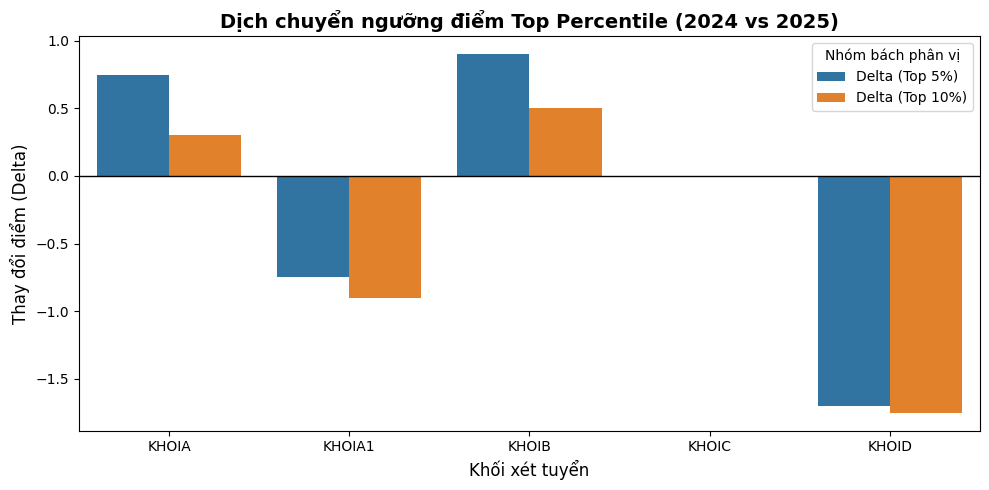

In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display # Import để dùng được display() nếu bạn không ở Colab

# Giả định master_df đã được định nghĩa trước đó
# master_df = pd.read_csv("diemthi.csv") 

blocks = {
    'khoia': ['toan', 'vatly', 'hoahoc'], 
    'khoia1': ['toan', 'vatly', 'ngoaingu'], 
    'khoib': ['toan', 'hoahoc', 'sinhhoc'], 
    'khoic': ['nguvan', 'lichsu', 'dialy'], 
    'khoid': ['toan', 'nguvan', 'ngoaingu']
}

def get_percentiles(df, year_val, curriculum_filter=None):
    """
    Hàm tính toán bách phân vị, đã được tối ưu để dùng chung cho mọi năm
    và tránh lỗi khi truyền thẳng df vào tham số thay vì dùng biến toàn cục.
    """
    # Lọc theo năm
    mask = df['year_exam'] == year_val
    
    # Lọc thêm theo chương trình học nếu có truyền tham số curriculum_filter
    if curriculum_filter:
        mask = mask & (df['curriculum'] == curriculum_filter)
        
    df_year = df[mask]
    results = []
    
    for block, subjects in blocks.items():
        # Kiểm tra xem có điểm tổng của khối chưa
        if block in df_year.columns and df_year[block].notna().any():
            scores = df_year[block].dropna()
        else:
            # RÀO LỖI: Chỉ tính tổng nếu tất cả các môn thuộc khối đó ĐỀU TỒN TẠI trong df
            valid_subjects = [sub for sub in subjects if sub in df_year.columns]
            if len(valid_subjects) == len(subjects):
                scores = df_year[valid_subjects].dropna(how='any').sum(axis=1)
            else:
                scores = pd.Series(dtype=float) # Bỏ qua nếu thiếu dữ liệu cột
                
        if not scores.empty:
            p95 = scores.quantile(0.95)
            p90 = scores.quantile(0.90)
            results.append({'Block': block.upper(), 'Top 5%': p95, 'Top 10%': p90})
            
    return pd.DataFrame(results)

# 1. Tính toán cho năm 2024
df_2024_p = get_percentiles(master_df, 2024)

# 2. Tính toán cho năm 2025 (Chỉ lấy CT2018)
df_2025_p = get_percentiles(master_df, 2025, curriculum_filter='CT2018')

# 3. Hợp nhất và Trực quan hóa
if not df_2024_p.empty and not df_2025_p.empty:
    comparison_df = df_2024_p.merge(df_2025_p, on='Block', suffixes=('_2024', '_2025'))
    comparison_df['Delta (Top 5%)'] = comparison_df['Top 5%_2025'] - comparison_df['Top 5%_2024']
    comparison_df['Delta (Top 10%)'] = comparison_df['Top 10%_2025'] - comparison_df['Top 10%_2024']
    
    display(comparison_df) # Hoặc dùng print(comparison_df)

    plt.figure(figsize=(10,5))
    plot_data = comparison_df.melt(id_vars='Block', value_vars=['Delta (Top 5%)', 'Delta (Top 10%)'])
    
    sns.barplot(data=plot_data, x='Block', y='value', hue='variable')
    plt.axhline(0, color='black', lw=1)
    
    # Định dạng lại biểu đồ cho đẹp
    plt.title('Dịch chuyển ngưỡng điểm Top Percentile (2024 vs 2025)', fontsize=14, fontweight='bold')
    plt.ylabel('Thay đổi điểm (Delta)', fontsize=12)
    plt.xlabel('Khối xét tuyển', fontsize=12)
    plt.legend(title='Nhóm bách phân vị')
    plt.tight_layout()
    plt.show()
else:
    print("Dữ liệu không đủ để thực hiện phân tích (Thiếu dữ liệu của 2024 hoặc 2025).")

### **Giải trình logic và Câu chuyện dữ liệu (Storytelling):**

Theo phương pháp luận của tác giả Maz The Analyst, việc chỉ nhìn vào điểm trung bình sẽ không phản ánh đúng áp lực cạnh tranh ở các trường đại học Top đầu. Kết quả phân tích Bách phân vị (Percentile) cho thấy:

1. **Phân biệt Mean và Percentile:** Dữ liệu cho thấy dù điểm trung bình có thể không biến động nhiều, nhưng ngưỡng **Top 5% (nhóm tinh hoa)** có thể dịch chuyển mạnh. Đây chính là nhóm đối tượng mà các trường đại học danh tiếng hướng tới.

2. **Chỉ số Delta (Biến động thực tế):** 
   - Nếu **Delta > 0**: Ngưỡng điểm xuất sắc đang tăng lên. Điều này có nghĩa là thí sinh năm 2025 học tốt hơn hoặc đề thi dễ hơn ở nhóm câu hỏi phân hóa, dẫn đến việc 'lạm phát' ở nhóm điểm cao.
   - Nếu **Delta < 0**: Nhóm điểm cao đang co lại, cho thấy đề thi có tính phân hóa mạnh hơn năm trước.

3. **Chiến lược chọn nguyện vọng (Actionable Insight):** 
   - Nếu một học sinh đạt 25 điểm khối A (đúng bằng điểm chuẩn năm 2024), nhưng dữ liệu Percentile cho thấy 25 điểm năm nay chỉ lọt Top 10%, trong khi năm ngoái 25 điểm lọt Top 5% -> **Vị thế cạnh tranh của học sinh này đã bị giảm sút.**
   - Để có cơ hội đậu tương đương năm ngoái vào một trường đang lấy 'Top 5% thí sinh', học sinh cần đạt mức điểm tương ứng với mốc 95th percentile của năm 2025 đã tính toán ở trên.

* **Question 4:** Tại các vùng điểm nóng cạnh tranh (từ 24 đến 28 điểm), số lượng thí sinh tích lũy dư thừa hay thiếu hụt bao nhiêu người so với năm 2024 ở từng khối thi; kết hợp với biến số về chỉ tiêu và phương thức xét tuyển, điểm chuẩn của các trường Đại học top đầu (như Bách Khoa, Ngoại Thương, Kinh Tế Quốc Dân,...) sẽ biến động theo xu hướng nào?

✅ 2024: 1,061,605 thí sinh (giữ nguyên duplicate)
✅ 2025: 1,131,136 thí sinh (giữ nguyên duplicate)

   KHOIA        → 2024: 343,800  |  2025: 162,200
   KHOIA1       → 2024: 329,761  |  2025: 147,636
   KHOIB        → 2024: 342,291  |  2025:  44,964
   KHOIC        → 2024: 704,008  |  2025: 297,368
   KHOID        → 2024: 908,866  |  2025: 356,523
   KHOIC01      → 2024: 337,425  |  2025: 345,011
   KHOID07      → 2024: 328,435  |  2025:  24,710
📁 Lưu ảnh từng khối vào folder: question4_issue


C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\1202424368.py:96: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\1202424368.py:98: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.savefig(fpath, dpi=150, bbox_inches='tight')


   💾 Đã lưu: question4_issue\KHOIA_2024_vs_2025_raw.png


C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\1202424368.py:96: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\1202424368.py:98: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.savefig(fpath, dpi=150, bbox_inches='tight')


   💾 Đã lưu: question4_issue\KHOIA1_2024_vs_2025_raw.png


...

C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\1202424368.py:96: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\1202424368.py:98: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.savefig(fpath, dpi=150, bbox_inches='tight')


   💾 Đã lưu: question4_issue\KHOIC01_2024_vs_2025_raw.png


C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\1202424368.py:96: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\1202424368.py:98: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.savefig(fpath, dpi=150, bbox_inches='tight')


   💾 Đã lưu: question4_issue\KHOID07_2024_vs_2025_raw.png

📊 Đang vẽ biểu đồ tổng hợp lớn...


C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\1202424368.py:202: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(h_pad=3, w_pad=2)
C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\1202424368.py:203: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(OUTPUT_DIR, 'combo_pho_diem_2024_vs_2025_raw.png'), dpi=150, bbox_inches='tight')
e:\VKU\DataAnalysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


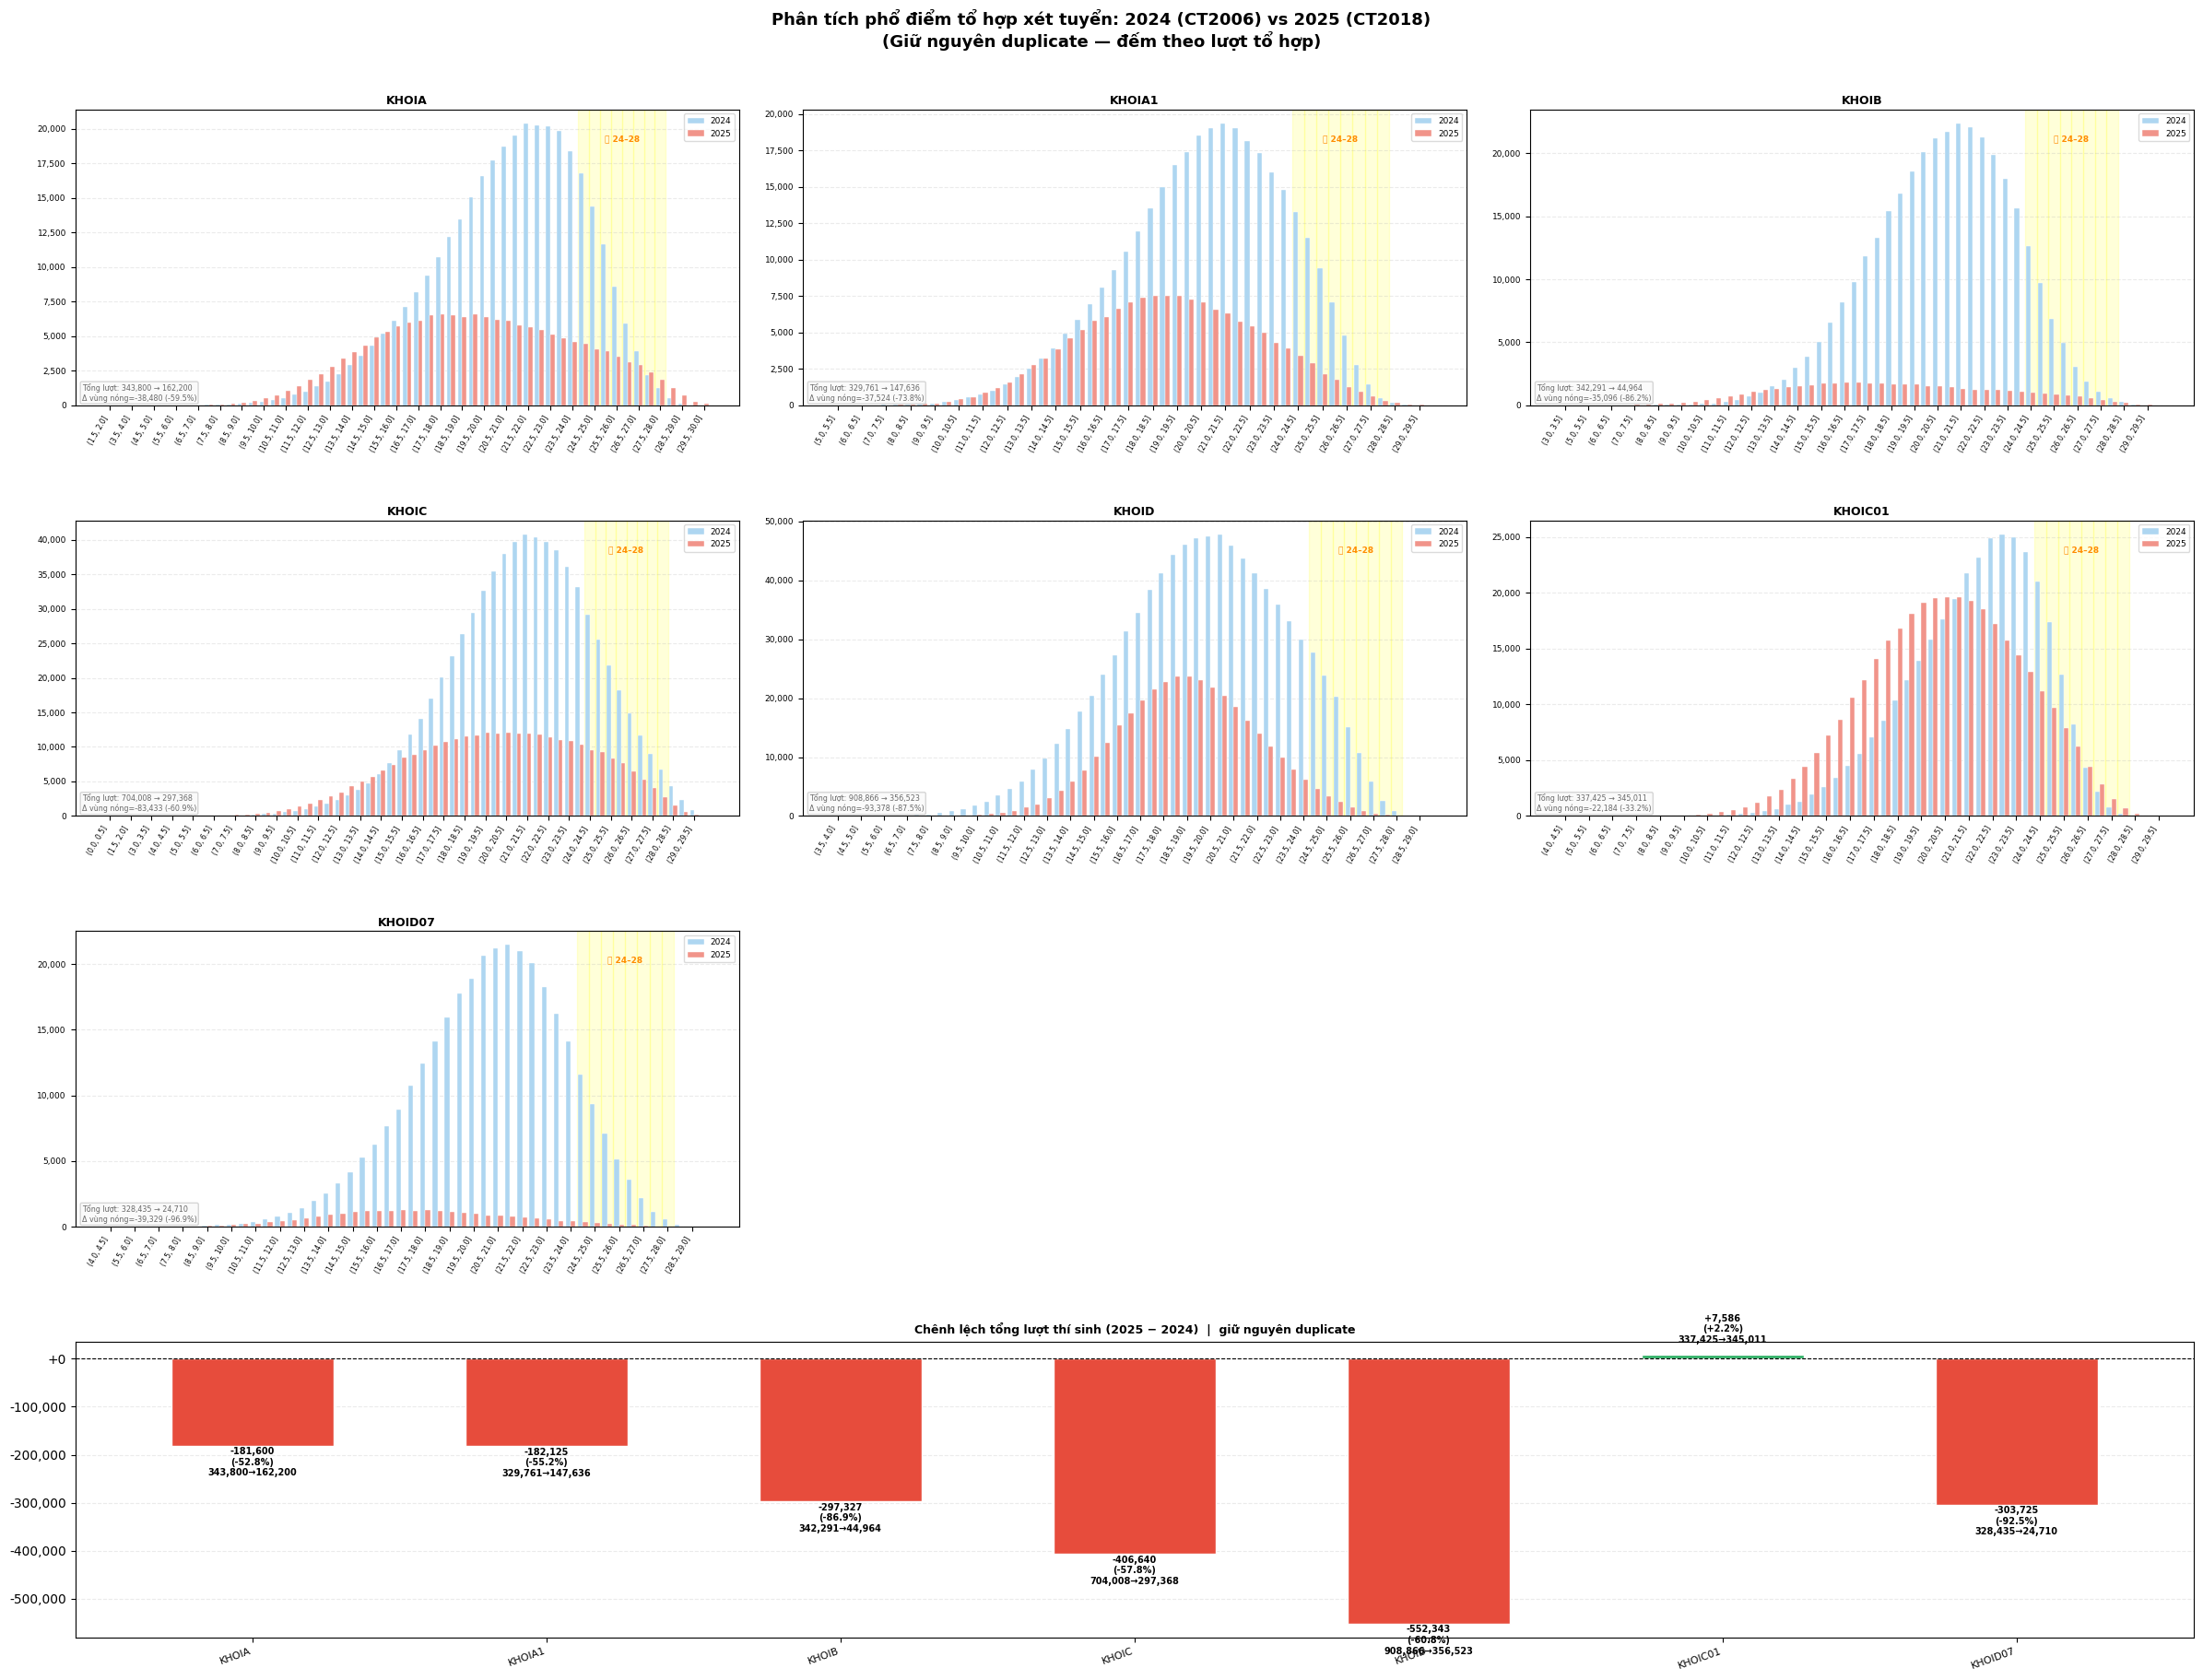

✅ Hoàn tất!


In [38]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# =============================================
# CẤU HÌNH
# =============================================
blocks_list = ['KHOIA', 'KHOIA1', 'KHOIB', 'KHOIC', 'KHOID', 'KHOIC01', 'KHOID07']
block_cols  = [b.lower() for b in blocks_list]

bins       = np.arange(0, 30.5, 0.5)
bin_labels = [f'({bins[i]:.1f}, {bins[i+1]:.1f}]' for i in range(len(bins)-1)]

YEAR1, YEAR2      = 2024, 2025
COLOR_Y1          = '#AED6F1'
COLOR_Y2          = '#F1948A'
HOT_LOW, HOT_HIGH = 24, 28
OUTPUT_DIR        = 'question4_issue'

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Filter thẳng, không deduplicate
df_2024 = master_df[(master_df['year_exam'] == YEAR1) & (master_df['curriculum'] == 'CT2006')].copy()
df_2025 = master_df[(master_df['year_exam'] == YEAR2) & (master_df['curriculum'] == 'CT2018')].copy()

print(f"✅ 2024: {len(df_2024):,} thí sinh (giữ nguyên duplicate)")
print(f"✅ 2025: {len(df_2025):,} thí sinh (giữ nguyên duplicate)\n")
for col in block_cols:
    n24 = df_2024[col].notna().sum()
    n25 = df_2025[col].notna().sum()
    print(f"   {col.upper():12s} → 2024: {n24:>7,}  |  2025: {n25:>7,}")


# =============================================
# BƯỚC 2: Lấy phân phối điểm
# =============================================
def get_dist(block, year):
    col = block.lower()
    src = df_2024 if year == YEAR1 else df_2025
    counts, _ = np.histogram(src[col].dropna(), bins=bins)
    return counts


# =============================================
# BƯỚC 3: Lưu ảnh nhỏ từng khối (không hiển thị)
# =============================================
def save_block_chart(block):
    c1 = get_dist(block, YEAR1)
    c2 = get_dist(block, YEAR2)

    if c1.sum() == 0 and c2.sum() == 0:
        print(f"⚠️  Bỏ qua {block}: không có dữ liệu")
        return 0, 0

    nz  = (c1 > 0) | (c2 > 0)
    lbl = [bin_labels[i] for i in range(len(bin_labels)) if nz[i]]
    c1f = c1[nz]
    c2f = c2[nz]
    x   = np.arange(len(lbl))
    w   = 0.4

    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.bar(x - w/2, c1f, w, label=f'{YEAR1} (CT2006)', color=COLOR_Y1, edgecolor='white', linewidth=0.3)
    ax.bar(x + w/2, c2f, w, label=f'{YEAR2} (CT2018)', color=COLOR_Y2, edgecolor='white', linewidth=0.3)

    hot_idx = [i for i, lb in enumerate(lbl)
               if any(f'({v:.1f},' in lb for v in np.arange(HOT_LOW, HOT_HIGH, 0.5))]
    for i in hot_idx:
        ax.axvspan(i - 0.5, i + 0.5, color='yellow', alpha=0.15, zorder=0)
    if hot_idx:
        mid  = (hot_idx[0] + hot_idx[-1]) / 2
        ymax = max(c1f.max(), c2f.max())
        ax.text(mid, ymax * 0.96, f'🔥 {HOT_LOW}–{HOT_HIGH}',
                ha='center', va='top', fontsize=8, color='darkorange', fontweight='bold')

    ax.set_xticks(x[::2])
    ax.set_xticklabels(lbl[::2], rotation=60, ha='right', fontsize=6)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax.set_title(f'Phổ điểm tổ hợp {block} — {YEAR1} vs {YEAR2} (có duplicate)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.set_axisbelow(True)

    t1, t2 = int(c1f.sum()), int(c2f.sum())
    h1 = int(c1f[hot_idx].sum()) if hot_idx else 0
    h2 = int(c2f[hot_idx].sum()) if hot_idx else 0
    dh = h2 - h1
    pct = (dh / h1 * 100) if h1 > 0 else 0
    fig.text(0.5, -0.01,
             f"Tổng lượt: {t1:,} → {t2:,}  |  Vùng nóng {HOT_LOW}–{HOT_HIGH}: {h1:,} → {h2:,}  |  Δ={dh:+,} ({pct:+.1f}%)",
             ha='center', fontsize=8, color='dimgray',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#f9f9f9', edgecolor='#ccc'))

    plt.tight_layout()
    fpath = os.path.join(OUTPUT_DIR, f'{block}_{YEAR1}_vs_{YEAR2}_raw.png')
    fig.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.close(fig)
    print(f"   💾 Đã lưu: {fpath}")
    return t1, t2


# =============================================
# BƯỚC 4: Subplot tổng hợp
# =============================================
def draw_summary_ax(ax, summary):
    blocks = [s['block'] for s in summary]
    t1_arr = np.array([s['t1'] for s in summary])
    t2_arr = np.array([s['t2'] for s in summary])
    deltas = t2_arr - t1_arr
    pcts   = np.where(t1_arr > 0, deltas / t1_arr * 100, 0)

    x      = np.arange(len(blocks))
    colors = ['#27AE60' if d >= 0 else '#E74C3C' for d in deltas]
    ax.bar(x, deltas, width=0.55, color=colors, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels(blocks, rotation=20, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):+,}'))
    ax.set_title(
        f'Chênh lệch tổng lượt thí sinh ({YEAR2} − {YEAR1})  |  giữ nguyên duplicate',
        fontsize=9, fontweight='bold', pad=6)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.set_axisbelow(True)

    rng = abs(deltas).max() if abs(deltas).max() > 0 else 1
    for i, (d, p, tb1, tb2) in enumerate(zip(deltas, pcts, t1_arr, t2_arr)):
        ypos = d + rng * (0.04 if d >= 0 else -0.12)
        ax.text(i, ypos, f'{d:+,}\n({p:+.1f}%)\n{tb1:,}→{tb2:,}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')


# =============================================
# BƯỚC 5: Chạy
# =============================================
summary = []
print("📁 Lưu ảnh từng khối vào folder:", OUTPUT_DIR)
for block in blocks_list:
    t1, t2 = save_block_chart(block)
    if t1 > 0 or t2 > 0:
        summary.append({'block': block, 't1': t1, 't2': t2})

# Combo lớn
n_cols = 3
n_rows = (len(blocks_list) + n_cols - 1) // n_cols + 1

print("\n📊 Đang vẽ biểu đồ tổng hợp lớn...")
fig = plt.figure(figsize=(n_cols * 8, n_rows * 4.5))
fig.suptitle(
    f'Phân tích phổ điểm tổ hợp xét tuyển: {YEAR1} (CT2006) vs {YEAR2} (CT2018)\n'
    f'(Giữ nguyên duplicate — đếm theo lượt tổ hợp)',
    fontsize=13, fontweight='bold', y=1.01
)

def draw_dist_ax(ax, block):
    c1 = get_dist(block, YEAR1)
    c2 = get_dist(block, YEAR2)
    if c1.sum() == 0 and c2.sum() == 0:
        ax.text(0.5, 0.5, f'{block}\nKhông có dữ liệu',
                ha='center', va='center', transform=ax.transAxes, color='gray')
        ax.axis('off')
        return
    nz  = (c1 > 0) | (c2 > 0)
    lbl = [bin_labels[i] for i in range(len(bin_labels)) if nz[i]]
    c1f, c2f = c1[nz], c2[nz]
    x, w = np.arange(len(lbl)), 0.4
    ax.bar(x - w/2, c1f, w, label=f'{YEAR1}', color=COLOR_Y1, edgecolor='white', linewidth=0.3)
    ax.bar(x + w/2, c2f, w, label=f'{YEAR2}', color=COLOR_Y2, edgecolor='white', linewidth=0.3)
    hot_idx = [i for i, lb in enumerate(lbl)
               if any(f'({v:.1f},' in lb for v in np.arange(HOT_LOW, HOT_HIGH, 0.5))]
    for i in hot_idx:
        ax.axvspan(i - 0.5, i + 0.5, color='yellow', alpha=0.15, zorder=0)
    if hot_idx:
        ax.text((hot_idx[0]+hot_idx[-1])/2, max(c1f.max(), c2f.max())*0.96,
                f'🔥 {HOT_LOW}–{HOT_HIGH}', ha='center', va='top',
                fontsize=6.5, color='darkorange', fontweight='bold')
    ax.set_xticks(x[::2])
    ax.set_xticklabels(lbl[::2], rotation=60, ha='right', fontsize=5.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax.tick_params(axis='y', labelsize=6.5)
    ax.set_title(block, fontsize=9, fontweight='bold', pad=4)
    ax.legend(fontsize=6.5, loc='upper right', framealpha=0.7)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.set_axisbelow(True)
    t1, t2 = int(c1f.sum()), int(c2f.sum())
    h1 = int(c1f[hot_idx].sum()) if hot_idx else 0
    h2 = int(c2f[hot_idx].sum()) if hot_idx else 0
    dh = h2 - h1
    pct = (dh / h1 * 100) if h1 > 0 else 0
    ax.text(0.01, 0.01, f"Tổng lượt: {t1:,} → {t2:,}\nΔ vùng nóng={dh:+,} ({pct:+.1f}%)",
            transform=ax.transAxes, fontsize=5.8, va='bottom', color='dimgray',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#f9f9f9', edgecolor='#ccc', alpha=0.8))

for i, block in enumerate(blocks_list):
    ax = fig.add_subplot(n_rows, n_cols, i + 1)
    draw_dist_ax(ax, block)

ax_summary = fig.add_subplot(n_rows, 1, n_rows)
draw_summary_ax(ax_summary, summary)

plt.tight_layout(h_pad=3, w_pad=2)
plt.savefig(os.path.join(OUTPUT_DIR, 'combo_pho_diem_2024_vs_2025_raw.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✅ Hoàn tất!")

Trình bày vấn đề


✅ 2024 dedup: 1,061,605 thí sinh
✅ 2025 dedup: 1,131,136 thí sinh

   KHOIA        → 2024:  78,182  |  2025:  55,375
   KHOIA1       → 2024:  40,877  |  2025:  20,616
   KHOIB        → 2024:  53,186  |  2025:  44,964
   KHOIC        → 2024: 618,116  |  2025: 297,368
   KHOID        → 2024: 160,995  |  2025: 222,272
   KHOIC01      → 2024:  87,982  |  2025: 253,765
   KHOID07      → 2024:  18,248  |  2025:   5,349
📁 Lưu ảnh từng khối vào folder: question4


C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\2982582776.py:112: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\2982582776.py:114: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.savefig(fpath, dpi=150, bbox_inches='tight')


   💾 Đã lưu: question4\KHOIA_2024_vs_2025.png


C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\2982582776.py:112: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\2982582776.py:114: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.savefig(fpath, dpi=150, bbox_inches='tight')


   💾 Đã lưu: question4\KHOIA1_2024_vs_2025.png


...

C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\2982582776.py:112: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\2982582776.py:114: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.savefig(fpath, dpi=150, bbox_inches='tight')


   💾 Đã lưu: question4\KHOIC01_2024_vs_2025.png


C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\2982582776.py:112: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\2982582776.py:114: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.savefig(fpath, dpi=150, bbox_inches='tight')


   💾 Đã lưu: question4\KHOID07_2024_vs_2025.png

📊 Đang vẽ biểu đồ tổng hợp lớn...


C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\2982582776.py:219: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(h_pad=3, w_pad=2)
C:\Users\GIGABYTE\AppData\Local\Temp\ipykernel_6264\2982582776.py:220: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig(os.path.join(OUTPUT_DIR, 'combo_pho_diem_2024_vs_2025.png'), dpi=150, bbox_inches='tight')
e:\VKU\DataAnalysis\venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


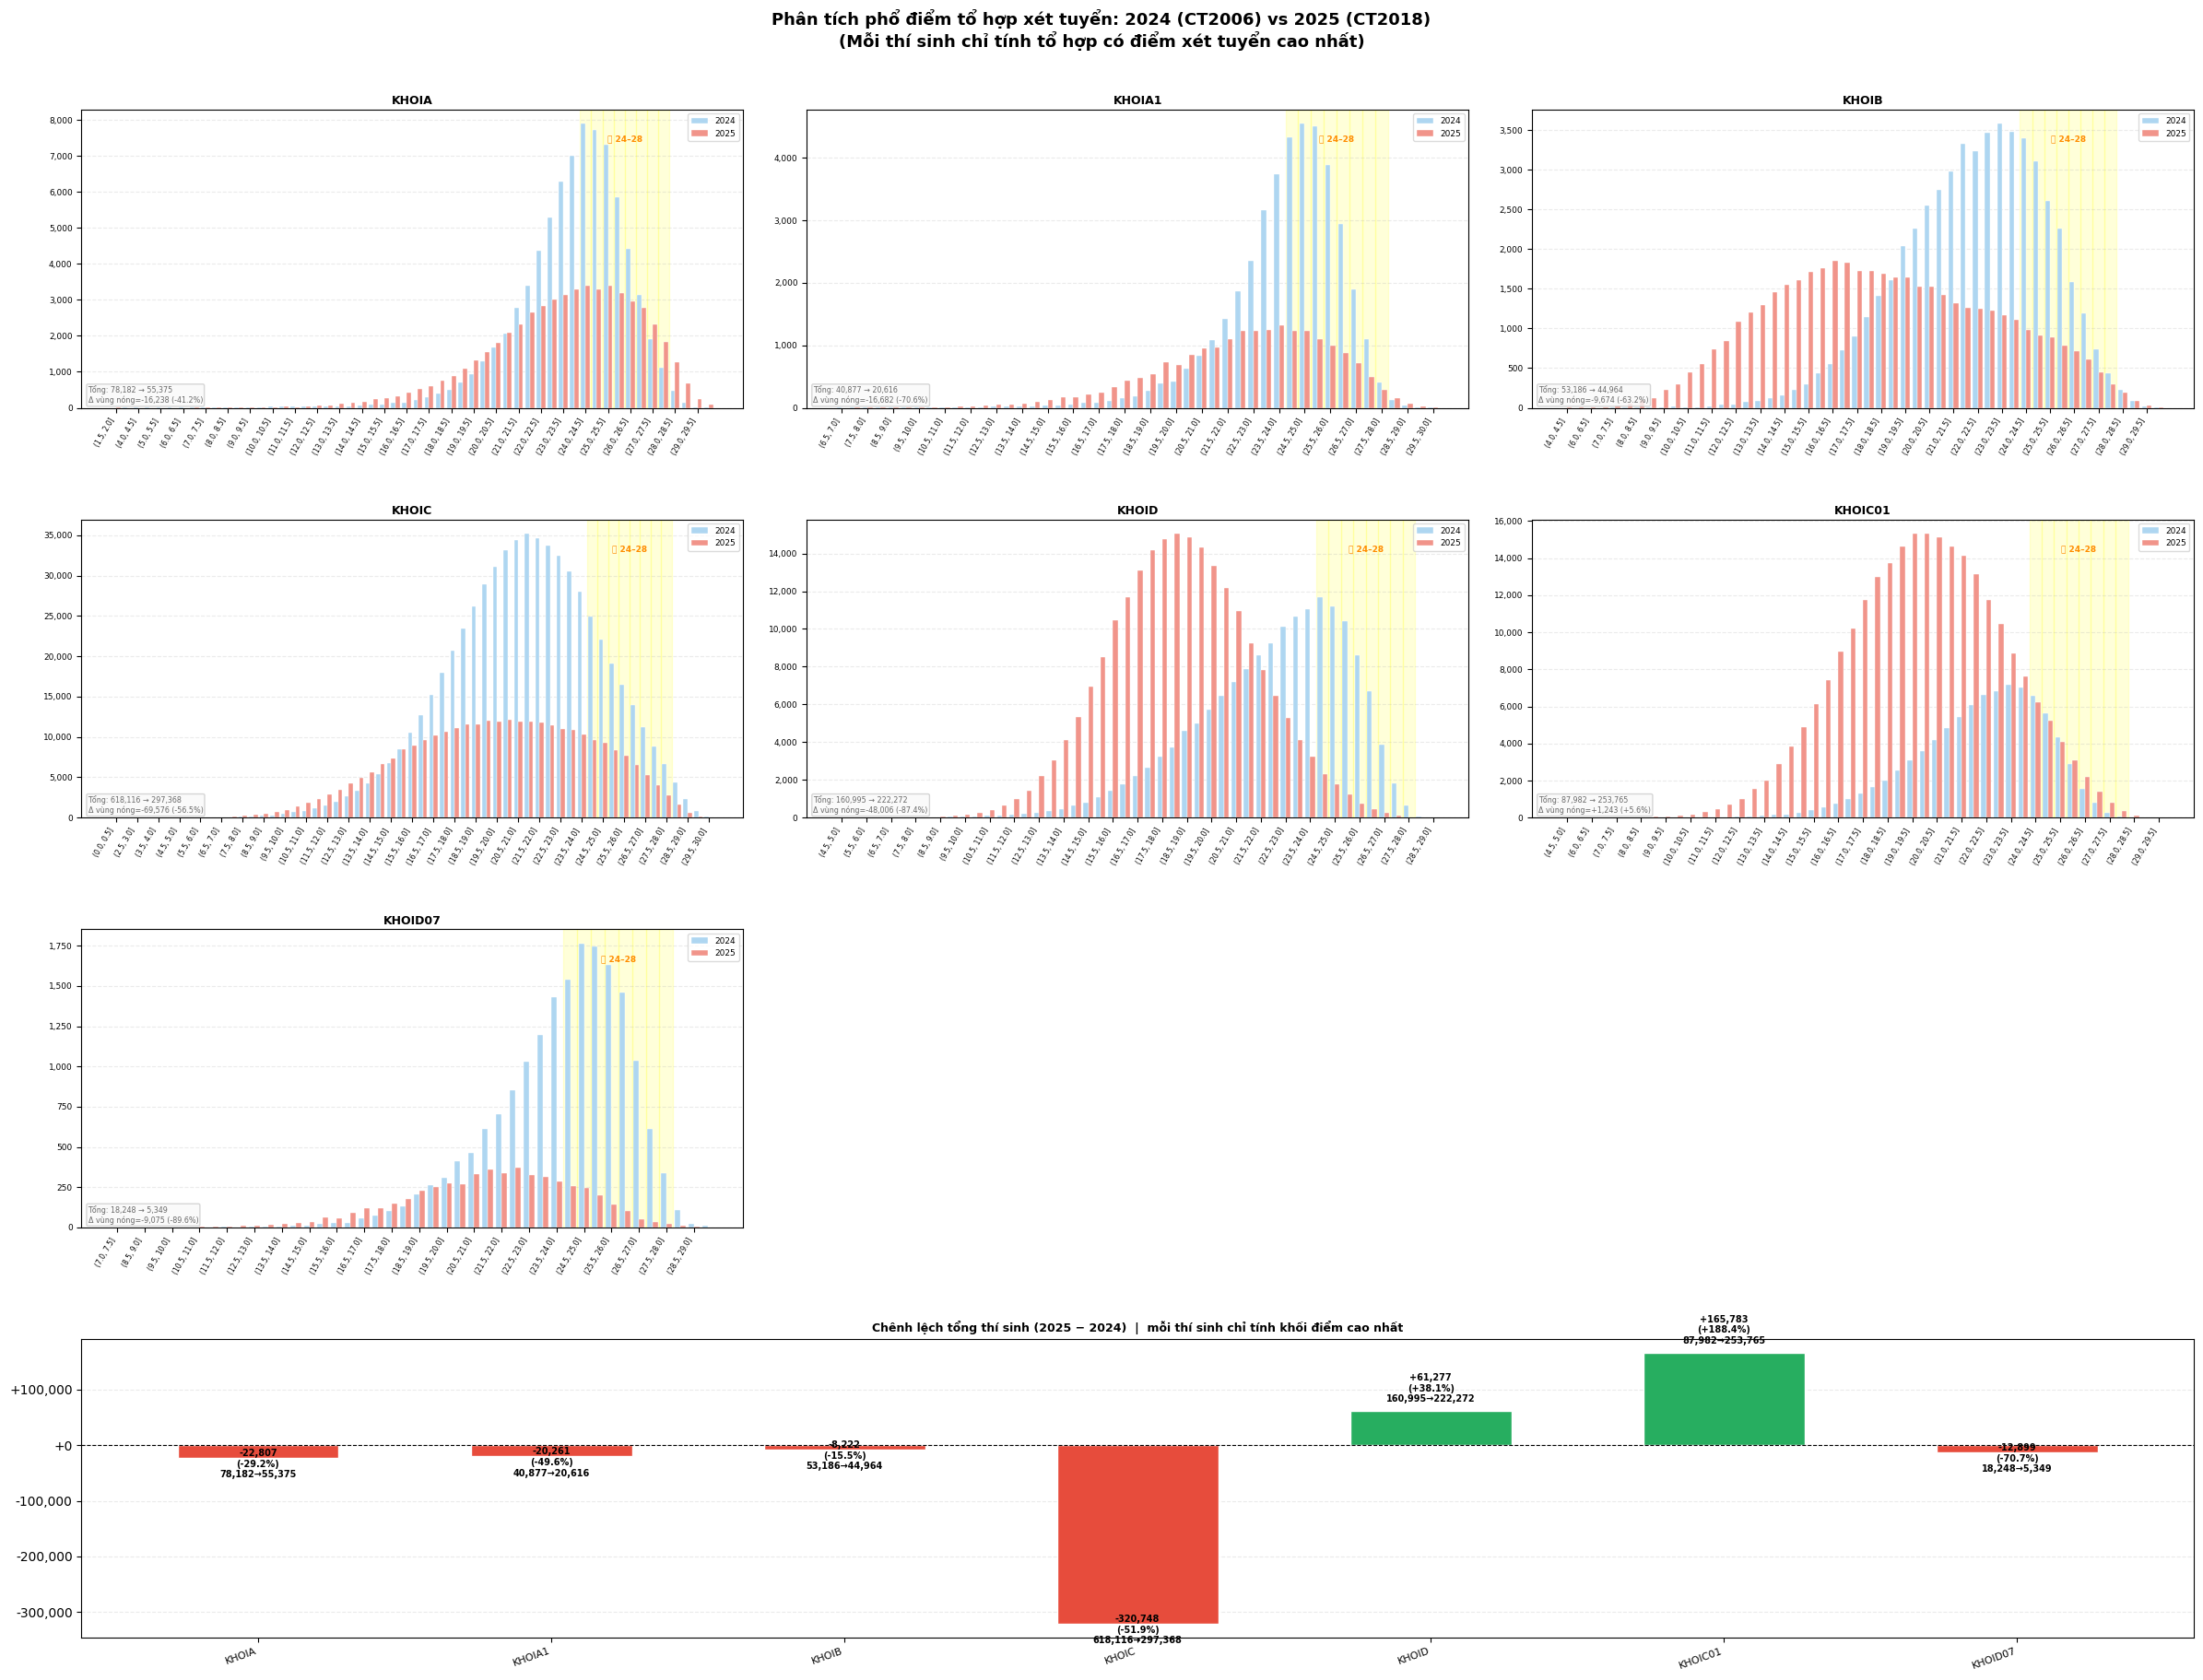

✅ Hoàn tất!


In [36]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# =============================================
# CẤU HÌNH
# =============================================
blocks_list = ['KHOIA', 'KHOIA1', 'KHOIB', 'KHOIC', 'KHOID', 'KHOIC01', 'KHOID07']
block_cols  = [b.lower() for b in blocks_list]
EXCLUDE_COLS = ['khoia02']

bins       = np.arange(0, 30.5, 0.5)
bin_labels = [f'({bins[i]:.1f}, {bins[i+1]:.1f}]' for i in range(len(bins)-1)]

YEAR1, YEAR2      = 2024, 2025
COLOR_Y1          = '#AED6F1'
COLOR_Y2          = '#F1948A'
HOT_LOW, HOT_HIGH = 24, 28
OUTPUT_DIR        = 'question4'

os.makedirs(OUTPUT_DIR, exist_ok=True)


# =============================================
# BƯỚC 1: Deduplicate
# =============================================
def deduplicate(df, year, curriculum):
    df_f = df[(df['year_exam'] == year) & (df['curriculum'] == curriculum)].copy()
    candidate_cols = [c for c in block_cols if c not in EXCLUDE_COLS]
    has_any = df_f[candidate_cols].notna().any(axis=1)
    best    = df_f.loc[has_any, candidate_cols].idxmax(axis=1)
    for col in block_cols + EXCLUDE_COLS:
        if col in df_f.columns:
            df_f[col] = np.nan
    for idx, best_col in best.items():
        df_f.at[idx, best_col] = df.at[idx, best_col]
    return df_f

df_2024 = deduplicate(master_df, YEAR1, 'CT2006')
df_2025 = deduplicate(master_df, YEAR2, 'CT2018')

print(f"✅ 2024 dedup: {len(df_2024):,} thí sinh")
print(f"✅ 2025 dedup: {len(df_2025):,} thí sinh\n")
for col in block_cols:
    n24 = df_2024[col].notna().sum()
    n25 = df_2025[col].notna().sum()
    print(f"   {col.upper():12s} → 2024: {n24:>7,}  |  2025: {n25:>7,}")


# =============================================
# BƯỚC 2: Lấy phân phối điểm
# =============================================
def get_dist(block, year):
    col = block.lower()
    src = df_2024 if year == YEAR1 else df_2025
    counts, _ = np.histogram(src[col].dropna(), bins=bins)
    return counts


# =============================================
# BƯỚC 3: Vẽ & lưu ảnh nhỏ từng khối (không hiển thị)
# =============================================
def save_block_chart(block):
    c1 = get_dist(block, YEAR1)
    c2 = get_dist(block, YEAR2)

    if c1.sum() == 0 and c2.sum() == 0:
        print(f"⚠️  Bỏ qua {block}: không có dữ liệu")
        return 0, 0

    nz  = (c1 > 0) | (c2 > 0)
    lbl = [bin_labels[i] for i in range(len(bin_labels)) if nz[i]]
    c1f = c1[nz]
    c2f = c2[nz]
    x   = np.arange(len(lbl))
    w   = 0.4

    fig, ax = plt.subplots(figsize=(14, 4.5))
    ax.bar(x - w/2, c1f, w, label=f'{YEAR1} (CT2006)', color=COLOR_Y1, edgecolor='white', linewidth=0.3)
    ax.bar(x + w/2, c2f, w, label=f'{YEAR2} (CT2018)', color=COLOR_Y2, edgecolor='white', linewidth=0.3)

    hot_idx = [i for i, lb in enumerate(lbl)
               if any(f'({v:.1f},' in lb for v in np.arange(HOT_LOW, HOT_HIGH, 0.5))]
    for i in hot_idx:
        ax.axvspan(i - 0.5, i + 0.5, color='yellow', alpha=0.15, zorder=0)
    if hot_idx:
        mid  = (hot_idx[0] + hot_idx[-1]) / 2
        ymax = max(c1f.max(), c2f.max())
        ax.text(mid, ymax * 0.96, f'🔥 {HOT_LOW}–{HOT_HIGH}',
                ha='center', va='top', fontsize=8, color='darkorange', fontweight='bold')

    ax.set_xticks(x[::2])
    ax.set_xticklabels(lbl[::2], rotation=60, ha='right', fontsize=6)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax.set_title(f'Phổ điểm tổ hợp {block} — {YEAR1} vs {YEAR2}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.set_axisbelow(True)

    t1, t2 = int(c1f.sum()), int(c2f.sum())
    h1 = int(c1f[hot_idx].sum()) if hot_idx else 0
    h2 = int(c2f[hot_idx].sum()) if hot_idx else 0
    dh = h2 - h1
    pct = (dh / h1 * 100) if h1 > 0 else 0
    fig.text(0.5, -0.01,
             f"Tổng: {t1:,} → {t2:,}  |  Vùng nóng {HOT_LOW}–{HOT_HIGH}: {h1:,} → {h2:,}  |  Δ={dh:+,} ({pct:+.1f}%)",
             ha='center', fontsize=8, color='dimgray',
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#f9f9f9', edgecolor='#ccc'))

    plt.tight_layout()
    fpath = os.path.join(OUTPUT_DIR, f'{block}_{YEAR1}_vs_{YEAR2}.png')
    fig.savefig(fpath, dpi=150, bbox_inches='tight')
    plt.close(fig)   # ← không hiển thị, đóng luôn
    print(f"   💾 Đã lưu: {fpath}")
    return t1, t2


# =============================================
# BƯỚC 4: Subplot tổng hợp
# =============================================
def draw_summary_ax(ax, summary):
    blocks = [s['block'] for s in summary]
    t1_arr = np.array([s['t1'] for s in summary])
    t2_arr = np.array([s['t2'] for s in summary])
    deltas = t2_arr - t1_arr
    pcts   = np.where(t1_arr > 0, deltas / t1_arr * 100, 0)

    x      = np.arange(len(blocks))
    colors = ['#27AE60' if d >= 0 else '#E74C3C' for d in deltas]
    ax.bar(x, deltas, width=0.55, color=colors, edgecolor='white')
    ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_xticks(x)
    ax.set_xticklabels(blocks, rotation=20, ha='right', fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):+,}'))
    ax.set_title(
        f'Chênh lệch tổng thí sinh ({YEAR2} − {YEAR1})  |  mỗi thí sinh chỉ tính khối điểm cao nhất',
        fontsize=9, fontweight='bold', pad=6)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.set_axisbelow(True)

    rng = abs(deltas).max() if abs(deltas).max() > 0 else 1
    for i, (d, p, tb1, tb2) in enumerate(zip(deltas, pcts, t1_arr, t2_arr)):
        ypos = d + rng * (0.04 if d >= 0 else -0.12)
        ax.text(i, ypos, f'{d:+,}\n({p:+.1f}%)\n{tb1:,}→{tb2:,}',
                ha='center', va='bottom', fontsize=7, fontweight='bold')


# =============================================
# BƯỚC 5: Chạy — lưu ảnh nhỏ, vẽ combo lớn
# =============================================
summary = []
print("📁 Lưu ảnh từng khối vào folder:", OUTPUT_DIR)
for block in blocks_list:
    t1, t2 = save_block_chart(block)
    if t1 > 0 or t2 > 0:
        summary.append({'block': block, 't1': t1, 't2': t2})

# --- Combo figure lớn: grid khối + hàng tổng hợp ---
n_cols = 3
n_rows = (len(blocks_list) + n_cols - 1) // n_cols + 1

print("\n📊 Đang vẽ biểu đồ tổng hợp lớn...")
fig = plt.figure(figsize=(n_cols * 8, n_rows * 4.5))
fig.suptitle(
    f'Phân tích phổ điểm tổ hợp xét tuyển: {YEAR1} (CT2006) vs {YEAR2} (CT2018)\n'
    f'(Mỗi thí sinh chỉ tính tổ hợp có điểm xét tuyển cao nhất)',
    fontsize=13, fontweight='bold', y=1.01
)

def draw_dist_ax(ax, block):
    """Vẽ inline vào ax (dùng cho combo lớn)."""
    c1 = get_dist(block, YEAR1)
    c2 = get_dist(block, YEAR2)
    if c1.sum() == 0 and c2.sum() == 0:
        ax.text(0.5, 0.5, f'{block}\nKhông có dữ liệu',
                ha='center', va='center', transform=ax.transAxes, color='gray')
        ax.axis('off')
        return
    nz  = (c1 > 0) | (c2 > 0)
    lbl = [bin_labels[i] for i in range(len(bin_labels)) if nz[i]]
    c1f, c2f = c1[nz], c2[nz]
    x, w = np.arange(len(lbl)), 0.4
    ax.bar(x - w/2, c1f, w, label=f'{YEAR1}', color=COLOR_Y1, edgecolor='white', linewidth=0.3)
    ax.bar(x + w/2, c2f, w, label=f'{YEAR2}', color=COLOR_Y2, edgecolor='white', linewidth=0.3)
    hot_idx = [i for i, lb in enumerate(lbl)
               if any(f'({v:.1f},' in lb for v in np.arange(HOT_LOW, HOT_HIGH, 0.5))]
    for i in hot_idx:
        ax.axvspan(i - 0.5, i + 0.5, color='yellow', alpha=0.15, zorder=0)
    if hot_idx:
        ax.text((hot_idx[0]+hot_idx[-1])/2, max(c1f.max(), c2f.max())*0.96,
                f'🔥 {HOT_LOW}–{HOT_HIGH}', ha='center', va='top',
                fontsize=6.5, color='darkorange', fontweight='bold')
    ax.set_xticks(x[::2])
    ax.set_xticklabels(lbl[::2], rotation=60, ha='right', fontsize=5.5)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{int(v):,}'))
    ax.tick_params(axis='y', labelsize=6.5)
    ax.set_title(block, fontsize=9, fontweight='bold', pad=4)
    ax.legend(fontsize=6.5, loc='upper right', framealpha=0.7)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.set_axisbelow(True)
    t1, t2 = int(c1f.sum()), int(c2f.sum())
    h1 = int(c1f[hot_idx].sum()) if hot_idx else 0
    h2 = int(c2f[hot_idx].sum()) if hot_idx else 0
    dh = h2 - h1
    pct = (dh / h1 * 100) if h1 > 0 else 0
    ax.text(0.01, 0.01, f"Tổng: {t1:,} → {t2:,}\nΔ vùng nóng={dh:+,} ({pct:+.1f}%)",
            transform=ax.transAxes, fontsize=5.8, va='bottom', color='dimgray',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='#f9f9f9', edgecolor='#ccc', alpha=0.8))

for i, block in enumerate(blocks_list):
    ax = fig.add_subplot(n_rows, n_cols, i + 1)
    draw_dist_ax(ax, block)

ax_summary = fig.add_subplot(n_rows, 1, n_rows)
draw_summary_ax(ax_summary, summary)

plt.tight_layout(h_pad=3, w_pad=2)
plt.savefig(os.path.join(OUTPUT_DIR, 'combo_pho_diem_2024_vs_2025.png'), dpi=150, bbox_inches='tight')
plt.show()   # ← chỉ hiển thị combo lớn
print("✅ Hoàn tất!")

Storytelling

* **Question 5:** Mối tương quan điểm số giữa các môn học (Ví dụ: Toán và Ngoại ngữ, hoặc Ngữ Văn và Lịch Sử) năm 2025 có sự thay đổi nào không? Những thí sinh học giỏi môn Tự nhiên có xu hướng đạt điểm cao môn Ngoại ngữ như các năm trước hay không?

In [ ]:
# Analysis for Question 5


**Justification:**

* **Question 6:** Bản đồ phân bổ trung vị điểm và "độ lệch chuẩn" năm 2025 cho thấy khoảng cách về năng lực học tập và chất lượng giáo dục giữa các thành phố lớn (Hà Nội, TP.HCM) với các khu vực miền núi/vùng ven đang thu hẹp hay ngày càng giãn rộng?

In [ ]:
# Analysis for Question 6


**Justification:**

### **5.2:** Reflection

Sau khi hoàn thành các bước trên, tôi đã có được một bộ dữ liệu sạch (master_df) hợp nhất từ năm 2021 đến 2025, bao gồm cả hai chương trình giáo dục cũ và mới.
Thông qua việc phân tích các câu hỏi nghiên cứu, chúng ta có thể đánh giá được sự biến động của phổ điểm, tốc độ tăng trưởng thí sinh và những thay đổi về mặt cấu trúc đề thi giữa hai chương trình học.

Trong tương lai, tôi sẽ đi sâu vào việc phân tích các yếu tố ảnh hưởng đến điểm số của thí sinh theo vùng miền và đánh giá hiệu quả của phương thức xét tuyển mới dựa trên dữ liệu thực tế này.

#### SUBMISSION

After completion, export the notebook as an HTML file for the project submission using the File > Download as... > HTML or PDF menu option.

Submit file “my_Project.zip” to Final Project includes:

    1. my_Project.html
    2. my _Project.ipynb
